# Lecture 7a — Geocoding, mapping, and the attribution gap

**AI-integrated Sustainable Finance (25881) · Lab 7a**

---

Lecture 7 argued that location is an ESG variable: it determines physical risk,
regulatory exposure, social licence and supply-chain concentration. This lab
turns that claim into code.

It also does something less usual. **The dataset we are about to use has four
documented defects**, and we are not going to hide them. Finding them is the
lab. An analyst who can load a file is common; an analyst who checks whether
the file is what it claims to be is not.

### What you will do

1. Verify a pinned data snapshot, and discover it is not what was ordered.
2. Geocode company addresses, and work out why half of them failed.
3. Inspect match *quality*, and see that a successful geocode is not one thing.
4. Reverse-geocode coordinates into jurisdictions.
5. Map headquarters against physical emissions, and measure the gap.
6. Build a country choropleth joining two independent sources.
7. Confront the attribution gap: we know where the emissions are, not whose.

### Requirements

`pandas`, `numpy`, `plotly`, `folium`, `scikit-learn`. Everything is read from
the teaching repository and cached locally, so the second run is offline.

In [26]:
import json
import numpy as np
import pandas as pd

import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
pio.templates.default = "plotly_white"

import folium
from folium.plugins import MarkerCluster, HeatMap

import esgdata as ed

# For work you intend to cite or submit, pin a commit SHA rather than a branch.
# A branch is a moving target -- the restatement problem from the lecture.
# ed.REF = "your-commit-sha-here"

print(f"repo: {ed.REPO}")
print(f"ref:  {ed.REF}   <- set this to a commit SHA before submitting")

repo: VitaliAlexeev/AI_SustainableFinance_2026
ref:  main   <- set this to a commit SHA before submitting


---
## 1. Verify the snapshot before you trust it

The data was collected with a command that asked for **Australia**. Let us
check what actually arrived.

In [2]:
ed.snapshot_health()

downloading climatetrace_sources.csv ... 13.2 MB, cached
downloading worldbank_esg_panel.csv ... 4.1 MB, cached
downloading worldbank_countries.csv ... 0.0 MB, cached
downloading geocode_cache.json ... 0.1 MB, cached


,check,value,note
0,Climate TRACE rows,"78,924",
1,Climate TRACE countries,211,requested 1 (AUS); the API filter did not apply
2,... of which Australian,"1,776",
3,... point facilities,"28,925",the rest are administrative aggregates
4,Climate TRACE owner populated,0%,v7 /sources does not return ownership
5,"Sectors truncated at 10,000",6 of 9,"pagination cap, not a census"
6,World Bank rows,"6,760",
7,World Bank fill rate,64.6%,
8,World Bank 2025 fill,14.8%,"publication lag, not absence of the world"
9,Economies incl. aggregates,260,"46 are aggregates, not countries"


Read that table slowly. Four things are wrong with a dataset that loads
perfectly and has no missing values in its key columns:

1. **211 countries, not one.** The Climate TRACE API accepted a country filter
   and ignored it. The download log said `AUS: 78,924 sources` because the
   script reported the country it *requested*.
2. **Six of nine sectors are truncated at exactly 10,000 rows.** That is a
   pagination limit, not a count of the world. What we have is "the largest
   emitters per sector", which is a biased sample by construction.
3. **`owner` is empty for every row.** The endpoint does not return it.
4. **Most rows are not facilities.** They are administrative areas.

Let us confirm the first one directly rather than taking the summary's word
for it.

In [3]:
raw = pd.read_csv(ed._fetch("climatetrace_sources.csv"), low_memory=False)

print("The 'iso3' column, as shipped:")
print(f"  unique values: {raw['iso3'].unique()}")
print("\nThe 'country' column, which came from the API:")
print(raw["country"].value_counts().head(8).to_string())
print(f"\n  ... {raw['country'].nunique()} countries in total")
print(f"\nAustralian rows: {(raw['country'] == 'AUS').sum():,} "
      f"of {len(raw):,} ({(raw['country'] == 'AUS').mean():.1%})")

The 'iso3' column, as shipped:
  unique values: <ArrowStringArray>
['AUS']
Length: 1, dtype: str

The 'country' column, which came from the API:
country
USA    12638
CHN    11157
IND     4444
RUS     4192
BRA     3772
IDN     2146
AUS     1776
JPN     1767

  ... 211 countries in total

Australian rows: 1,776 of 78,924 (2.3%)


`iso3` records what was *asked for*. `country` records what *is*. They disagree
for 97.7% of rows, and nothing about the file's structure hints at the problem.

`esgdata.load_climatetrace()` drops the broken column and promotes `country`
into its place, so the rest of this notebook cannot use the wrong one by
accident.

> **The general lesson.** Provenance is not a nice-to-have. A column recording
> "what the pipeline intended" will eventually be mistaken for "what happened",
> and no amount of downstream cleverness recovers from it.

In [4]:
ct = ed.load_climatetrace()
print(f"{len(ct):,} sources, {ct['iso3'].nunique()} countries "
      f"(iso3 now corrected)")

manifest = ed.load_manifest()
entry = manifest["sources"]["climatetrace_AUS"]
print(f"\nretrieved: {entry['retrieved_utc']}")
print(f"endpoint:  {entry['endpoint']}")
print(f"year/gas:  {entry['year']} / {entry['gas']}")
print(f"columns the fetcher matched: {entry['matched_columns']}")

78,924 sources, 211 countries (iso3 now corrected)
downloading MANIFEST.json ... 0.0 MB, cached

retrieved: 2026-08-31T00:02:44Z
endpoint:  https://api.climatetrace.org/v7/sources
year/gas:  2024 / co2e_100yr
columns the fetcher matched: {'emissions': 'emissionsQuantity', 'id': 'id', 'lat': 'centroid.latitude', 'lon': 'centroid.longitude', 'name': 'name', 'owner': None, 'sector': 'sector'}


Note `'owner': None` in the matched columns. The fetcher looked for an owner
field, did not find one, and **recorded that fact**. That single line in the
manifest is the difference between a known limitation and a mystery.

---
## 2. Not everything with a coordinate is a place

Climate TRACE mixes two kinds of row, and they are not interchangeable.

In [5]:
aus_all = ed.load_climatetrace(country="AUS")

summary = (aus_all.groupby("sector")
           .agg(n=("source_id", "size"),
                unique_coords=("lat", lambda s: s.round(4).nunique()),
                example=("source_name", "first"))
           .assign(coord_reuse=lambda d: 1 - d.unique_coords / d.n)
           .sort_values("coord_reuse", ascending=False))
summary.round(2)

,n,unique_coords,example,coord_reuse
sector,,,,
forestry-and-land-use,419,180,Roper Gulf Shire,0.57
agriculture,234,169,Barkly Shire,0.28
fossil-fuel-operations,169,147,Australia_North Carnarvon_LNG,0.13
transportation,291,276,Sydney Kingsford Smith International Airport,0.05
buildings,100,97,Brisbane City,0.03
waste,216,214,Buttonderry Waste Management Facility,0.01
power,162,161,Bayswater power station,0.01
manufacturing,35,35,Pinjarra Alcoa Alumina Refinery,0.00
mineral-extraction,150,150,Roy Hill Mine,0.00


Look at the examples. `power` gives you *Bayswater power station*.
`forestry-and-land-use` gives you *Roper Gulf Shire*. `buildings` gives you
*Brisbane City*.

A shire is not a facility. Its coordinate is the **centroid of a polygon**, so
a marker there means "somewhere in this 200,000 km² area", not "here". Plotting
it next to a power station implies a precision that does not exist.

Worse, the aggregates dominate the emissions ranking, so a naive "top emitters"
map of Australia is mostly local-government areas.

In [6]:
print("Top 5 Australian 'sources' by emissions, unfiltered:")
print(aus_all.nlargest(5, "emissions_quantity")
      [["source_name", "sector", "emissions_quantity"]].to_string(index=False))

aus = ed.load_climatetrace(country="AUS", point_sources_only=True)
print(f"\nAfter keeping only point facilities: {len(aus)} of {len(aus_all)} rows")
print("\nTop 5 actual facilities:")
print(aus.nlargest(5, "emissions_quantity")
      [["source_name", "sector", "emissions_quantity"]].to_string(index=False))

Top 5 Australian 'sources' by emissions, unfiltered:
     source_name                sector  emissions_quantity
Roper Gulf Shire forestry-and-land-use        4.760580e+07
    Barkly Shire forestry-and-land-use        4.238765e+07
  Manjimup Shire forestry-and-land-use        3.563933e+07
      Cook Shire forestry-and-land-use        3.528036e+07
      Cook Shire forestry-and-land-use        3.106402e+07

After keeping only point facilities: 516 of 1776 rows

Top 5 actual facilities:
                  source_name                 sector  emissions_quantity
Australia_North Carnarvon_LNG fossil-fuel-operations        3.097113e+07
  Australia_Bowen - Surat_LNG fossil-fuel-operations        2.393097e+07
      Bayswater power station                  power        1.614450e+07
     Loy Yang A power station                  power        1.606160e+07
        Eraring power station                  power        1.540980e+07


> **Core exercise 2.1** — `ed.POINT_SECTORS` is a judgement call, not a fact
> from the data. Inspect `source_name` for `waste` and `transportation` and
> decide for yourself whether they belong. Document your choice; someone
> reading your map is entitled to know what a dot means.

---
## 3. Geocoding, and why half of it failed

Forward geocoding turns an address into coordinates. The snapshot geocoded 250
SEC business addresses and resolved 127. A 49% failure rate is high enough that
the *pattern* of failure matters more than the successes.

In [7]:
gc = ed.load_geocode_cache()
edgar = ed.load_edgar()

print(f"{len(gc)} attempts, {gc['resolved'].sum()} resolved "
      f"({gc['resolved'].mean():.0%})")

print("\nA sample that FAILED:")
for q in gc.loc[~gc["resolved"], "query"].head(6):
    print("   ", q)
print("\nA sample that WORKED:")
for q in gc.loc[gc["resolved"], "query"].head(4):
    print("   ", q)

downloading edgar_companies.csv ... 0.0 MB, cached
250 attempts, 127 resolved (51%)

A sample that FAILED:
    'hdfc bank house', senapati bapat road, lower parel (west), mumbai india, mumbai
    1 churchill place, canary wharf, london, x0, e14 5hp
    1 first canadian place, toronto, a6, m5x 1a1
    1 francis crick avenue, cambridge biomedical campus, cambridge, cb2 0aa
    1 grand canal square, grand canal harbour, dublin, l2, d2
    1 health drive, eden prairie, mn, 55344

A sample that WORKED:
    1 customer drive, bentonville, ar, 72716
    1 ecolab place, saint paul, mn, 55102
    1 meta way, menlo park, ca, 94025
    1 monster way, corona, ca, 92879


Stare at the failures for a moment before reading on.

`1 churchill place, canary wharf, london, **x0**, e14 5hp`
`1 first canadian place, toronto, **a6**, m5x 1a1`
`1-2, marunouchi 1-chome, chiyoda-ku, tokyo, **m0**, 100-0005`

`x0`, `a6`, `m0` are not typos. They are **EDGAR's proprietary state and
country codes**, which are not ISO codes and mean nothing to a geocoder. `X0`
is the United Kingdom. `A6` is Ontario. `M0` is Japan.

This is the identifier-mismatch problem from the lecture, causing real,
systematic data loss. And the loss is not random: it falls entirely on
**foreign-domiciled filers**.

In [8]:
# Attach the failure flag back to the filers, matching on the normalised query
gc_key = gc.assign(key=gc["query"].str.lower().str.replace(r"\s+", " ",
                                                           regex=True).str.strip())
ed_key = edgar.assign(key=edgar["hq_address"].str.lower()
                      .str.replace(r"\s+", " ", regex=True).str.strip())
joined = ed_key.merge(gc_key[["key", "resolved"]], on="key", how="left")
joined["resolved"] = joined["resolved"].fillna(False)

rate = (joined.groupby("is_foreign_code")["resolved"]
        .agg(["size", "sum", "mean"])
        .rename(columns={"size": "n", "sum": "resolved", "mean": "rate"}))
rate.index = ["US state code", "EDGAR foreign code"]
print(rate.round(3).to_string())

overall = joined["resolved"].mean()
print(f"\nOverall success: {overall:.0%}")
print("Missingness that depends on where a firm is domiciled is not MCAR.")

                      n  resolved   rate
US state code       199       127  0.638
EDGAR foreign code   51         0  0.000

Overall success: 51%
Missingness that depends on where a firm is domiciled is not MCAR.


There is a second cause too. Geocoders cannot use suite numbers, floors or
PO boxes, and their presence frequently sinks an otherwise-good address.

In [9]:
import re
noise = re.compile(r"\b(suite|ste\.?|floor|fl\.?|unit|level|room|rm\.?|"
                   r"p\.?\s?o\.?\s?box|mailstop)\b", re.I)
gc["has_noise"] = gc["query"].str.contains(noise)

print(pd.crosstab(gc["has_noise"], gc["resolved"],
                  rownames=["contains suite/floor/PO"],
                  colnames=["resolved"]).to_string())
print(f"\nsuccess rate with noise:    "
      f"{gc.loc[gc['has_noise'], 'resolved'].mean():.0%}")
print(f"success rate without noise: "
      f"{gc.loc[~gc['has_noise'], 'resolved'].mean():.0%}")

C:\Users\Vitali\AppData\Local\Temp\ipykernel_44720\1570247970.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  gc["has_noise"] = gc["query"].str.contains(noise)


resolved                 False  True 
contains suite/floor/PO              
False                       80    125
True                        43      2

success rate with noise:    4%
success rate without noise: 61%


### The fix

`esgdata.clean_sec_address()` translates the EDGAR codes and strips the noise.
Both fixes are cheap; neither is glamorous; together they would have recovered
most of the lost half.

In [10]:
show = edgar.loc[edgar["is_foreign_code"],
                 ["name", "hq_state_or_country", "hq_address",
                  "hq_address_clean"]].head(6)
for _, r in show.iterrows():
    print(f"{r['name'][:30]}  [{r['hq_state_or_country']}]")
    print(f"   before: {r['hq_address']}")
    print(f"   after:  {r['hq_address_clean']}\n")

print(f"filers with a foreign EDGAR code: {edgar['is_foreign_code'].sum()} of "
      f"{len(edgar)}")

ASML HOLDING NV  [P7]
   before: DE RUN 6501, DR VELDHOVEN, P7, 5504
   after:  DE RUN 6501, DR VELDHOVEN, Netherlands, 5504

HSBC HOLDINGS PLC  [X0]
   before: 8 CANADA SQUARE, LONDON, X0, E145HQ
   after:  8 CANADA SQUARE, LONDON, United Kingdom, E145HQ

NOVARTIS AG  [V8]
   before: LICHTSTRASSE 35, BASEL, V8, CH 4056
   after:  LICHTSTRASSE 35, BASEL, Switzerland, CH 4056

ARM HOLDINGS PLC /UK  [X0]
   before: 110 FULBOURN ROAD, CAMBRIDGE, X0, CB1 9NJ
   after:  110 FULBOURN ROAD, CAMBRIDGE, United Kingdom, CB1 9NJ

SAP SE  [2M]
   before: DIETMAR-HOPP-ALLEE 16, WALLDORF, 2M, 69190
   after:  DIETMAR-HOPP-ALLEE 16, WALLDORF, Germany, 69190

MITSUBISHI UFJ FINANCIAL GROUP  [M0]
   before: 4-5, MARUNOUCHI 1-CHOME, CHIYODA-KU, TOKYO, M0, 100-8330
   after:  4-5, MARUNOUCHI 1-CHOME, CHIYODA-KU, TOKYO, Japan, 100-8330

filers with a foreign EDGAR code: 51 of 250


> **Core exercise 3.1** — `ed.SEC_COUNTRY_CODES` is **partial**, and an earlier
> version of it had four entries wrong: `I0` was recorded as Israel when it is
> France, `P7` as Singapore when it is the Netherlands, `U0` as Sweden when it
> is Singapore. They were caught only by checking each code against a filer
> whose city was recognisable.
>
> Find every code in `edgar_companies.csv` that is **not** in the table. For
> each, identify the country from the company and city. Then say what this
> exercise implies about crosswalks you inherit from someone else.
>
> **Stretch exercise 3.2** — Re-run the geocoder on `hq_address_clean` using
> `geopy` with a 1.1 s rate limit and your own contact email. Report the new
> success rate, split by `is_foreign_code`. Did the gap close?

---
## 4. A successful geocode is not one thing

The 127 that worked did not all work equally well. Nominatim returns the
*kind* of object it matched, and the range is wide.

In [11]:
geo = ed.load_geocoded()

quality = (geo.groupby(["class", "type"]).size()
           .reset_index(name="n").sort_values("n", ascending=False))

PRECISION = {"building": "building footprint",
             "office": "building footprint",
             "place": "address point or locality",
             "amenity": "specific venue",
             "highway": "THE STREET, not the address",
             "boundary": "an administrative area",
             "information": "a map annotation"}
quality["what it means"] = quality["class"].map(PRECISION)
print(quality.head(12).to_string(index=False))

by_class = geo["class"].value_counts(normalize=True)
print(f"\nStreet-level ('highway') matches: {by_class.get('highway', 0):.0%}")
print(f"Locality-level ('place') matches: {by_class.get('place', 0):.0%}")

downloading geocoded_addresses.csv ... 0.0 MB, cached
   class              type  n               what it means
   place             house 32   address point or locality
  office           company 15          building footprint
building        commercial 14          building footprint
building            office 13          building footprint
building               yes 13          building footprint
 highway           primary  6 THE STREET, not the address
 highway       residential  4 THE STREET, not the address
 highway         secondary  4 THE STREET, not the address
 highway          tertiary  3 THE STREET, not the address
  office telecommunication  3          building footprint
  office               yes  2          building footprint
 highway          bus_stop  2 THE STREET, not the address

Street-level ('highway') matches: 17%
Locality-level ('place') matches: 25%


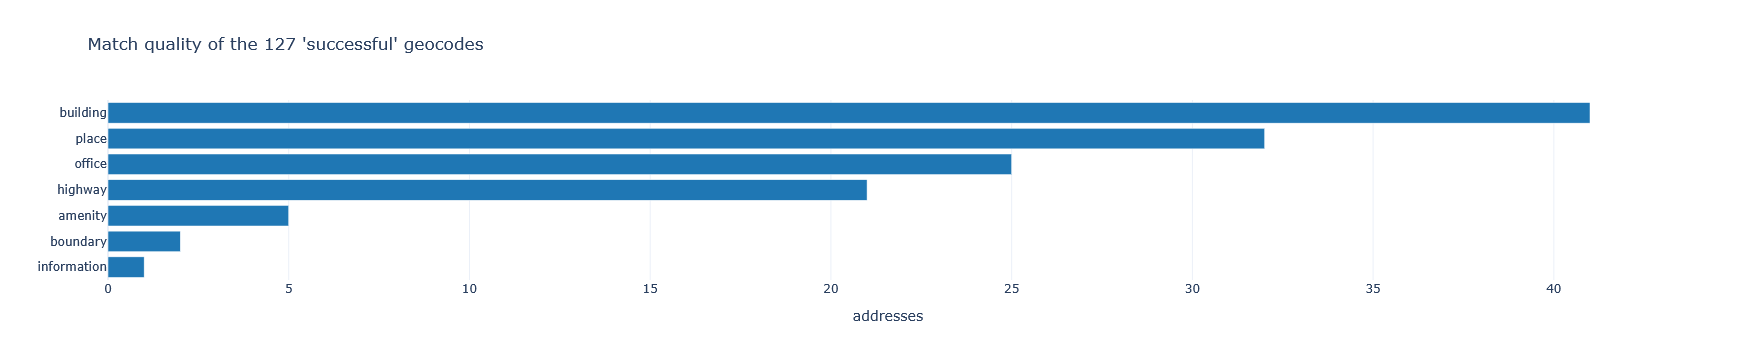

In [12]:
fig = px.bar(geo["class"].value_counts().reset_index(),
             x="count", y="class", orientation="h",
             title="Match quality of the 127 'successful' geocodes",
             labels={"count": "addresses", "class": ""})
fig.update_traces(marker_color="#1f77b4")
fig.update_layout(height=360, yaxis={"categoryorder": "total ascending"})
fig.show()

About a fifth of the successes matched a **road**, not a building. On a map at
country scale that is invisible. At city scale it can be hundreds of metres
out, and for anything involving flood zones or site boundaries that is the
difference between exposed and not.

> **Keeping the quality field is not optional.** Discarding it converts a
> heterogeneous set of measurements into a uniform-looking one, which is an
> undisclosed imputation of precision you do not have.

---
## 5. Reverse geocoding: coordinates to jurisdiction

The reverse operation is what turns a physical asset into a *regulatory*
exposure. Which country's carbon price applies to this coordinate? Which
disclosure regime captures it?

Live reverse geocoding is rate-limited, so here we do the same job offline
using the World Bank country table and a nearest-capital assignment. It is
crude, and the exercise asks you to say exactly how crude.

<details>
<summary><b>Maths: Nearest-neighbour assignment on a sphere</b> (click to expand)</summary>

For an asset at $(\phi_a, \lambda_a)$ and candidate reference points
$(\phi_i, \lambda_i)$, the great-circle distance is

$$d_i = 2R \arcsin\sqrt{\sin^2\!\Big(\tfrac{\phi_i-\phi_a}{2}\Big)
  + \cos\phi_a\cos\phi_i \sin^2\!\Big(\tfrac{\lambda_i-\lambda_a}{2}\Big)}$$

and the assignment is $\arg\min_i d_i$, with $R \approx 6371$ km.

**Why this is a poor proxy for jurisdiction.** It assigns by proximity to a
*capital city*, but borders are not Voronoi cells around capitals. An asset in
northern Mexico is closer to Washington than to Mexico City. Real reverse
geocoding tests point-in-polygon against actual boundaries. Use this only to
understand the operation, never to produce a number you would defend.

</details>

In [13]:
from sklearn.neighbors import BallTree

countries = ed.load_worldbank_countries()
caps = countries.dropna(subset=["lat", "lon"]).copy()

tree = BallTree(np.radians(caps[["lat", "lon"]].to_numpy()), metric="haversine")

sample = ct[ed.is_point_source(ct)].nlargest(2000, "emissions_quantity").copy()
dist, idx = tree.query(np.radians(sample[["lat", "lon"]].to_numpy()), k=1)

sample["nearest_capital"] = caps.iloc[idx.ravel()]["country"].to_numpy()
sample["nearest_iso3"] = caps.iloc[idx.ravel()]["iso3"].to_numpy()
sample["km_to_capital"] = dist.ravel() * 6371

agree = (sample["nearest_iso3"] == sample["iso3"]).mean()
print(f"Nearest-capital assignment agrees with the true country "
      f"{agree:.1%} of the time.")
print("\nWhere it disagrees, sorted by distance:")
print(sample.loc[sample["nearest_iso3"] != sample["iso3"]]
      .nsmallest(6, "km_to_capital")
      [["source_name", "iso3", "nearest_iso3", "km_to_capital"]]
      .round(0).to_string(index=False))

Nearest-capital assignment agrees with the true country 56.2% of the time.

Where it disagrees, sorted by distance:
                                       source_name iso3 nearest_iso3  km_to_capital
                              Alkhobar power plant  SAU          BHR           33.0
                         Tanjung Bin power station  MYS          SGP           35.0
AG der Dillinger Hüttenwerke Dillingen steel plant  DEU          LUX           53.0
                           Qurayyah CC power plant  SAU          BHR           56.0
                      Qurayyah Thermal power plant  SAU          BHR           57.0
           Cameroon_Niger Delta_Conventional shelf  CMR          GNQ           58.0


The agreement rate is the point. A plausible-looking spatial method, applied
without checking, would have mislabelled the jurisdiction of a large minority
of assets — and every one of those errors would propagate into a carbon-price
exposure estimate.

> **Stretch exercise 5.1** — Replace the capital-city proxy with a real
> point-in-polygon test using country boundaries (`geopandas` and a Natural
> Earth shapefile, or Climate TRACE's own geopackage). Report the new agreement
> rate against the `iso3` column.

---
## 6. Headquarters is not footprint

The central map of the lecture. We plot two things that are routinely confused:
where a company is *registered*, and where its emissions physically *occur*.

In [14]:
geo_join = (edgar.assign(key=edgar["hq_address"].str.lower()
                         .str.replace(r"\s+", " ", regex=True).str.strip())
            .merge(gc.loc[gc["resolved"], ["query", "lat", "lon", "class"]]
                   .assign(key=lambda d: d["query"].str.lower()
                           .str.replace(r"\s+", " ", regex=True).str.strip()),
                   on="key", how="inner"))

print(f"{len(geo_join)} filers with usable HQ coordinates")

top_emitters = ct[ed.is_point_source(ct)].nlargest(3000, "emissions_quantity")
print(f"{len(top_emitters):,} point facilities to plot")

127 filers with usable HQ coordinates
3,000 point facilities to plot


In [24]:
m = folium.Map(location=[20, 10], zoom_start=2, tiles="OpenStreetMap") # try "OpenStreetMap", "Esri.WorldGrayCanvas", "OpenTopoMap" or others like "cartodbpositron" (requires API key [free])

hq_layer = folium.FeatureGroup(name="Company headquarters (SEC filers)")
for _, r in geo_join.iterrows():
    folium.CircleMarker(
        [r["lat"], r["lon"]], radius=4, color="#1f77b4", fill=True,
        fill_opacity=0.85, weight=1,
        popup=folium.Popup(f"<b>{r['name']}</b><br>{r['ticker']}<br>"
                           f"<i>{r['sic_description']}</i><br>"
                           f"match: {r['class']}", max_width=280),
    ).add_to(hq_layer)
hq_layer.add_to(m)

fac_layer = folium.FeatureGroup(name="Emitting facilities (Climate TRACE)")
cluster = MarkerCluster().add_to(fac_layer)
for _, r in top_emitters.head(1200).iterrows():
    folium.CircleMarker(
        [r["lat"], r["lon"]], radius=3, color="#d62728", fill=True,
        fill_opacity=0.6, weight=0,
        popup=folium.Popup(f"<b>{r['source_name']}</b><br>{r['sector']}<br>"
                           f"{r['emissions_quantity']:,.0f} t CO2e",
                           max_width=280),
    ).add_to(cluster)
fac_layer.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)
m

Toggle the two layers against each other.

The blue dots cluster in California, New York and Western Europe. The red dots
cluster in China, India, the US Gulf Coast, the Persian Gulf and Australia's
mining regions. **They are almost disjoint.**

That is the argument in one image. A portfolio's geographic exposure computed
from registered offices measures where lawyers and tax advisers are, not where
climate risk lands.

If you do decide to get a tile map with API KEY, you could use it as follows (insert YOUR_KEY sent to you after registration at https://carto.com/basemaps/apikey/):

```python
m = folium.Map(location=[20, 10], zoom_start=2, tiles=None)
folium.TileLayer(
    tiles="https://basemaps.cartocdn.com/rastertiles/light_all/{z}/{x}/{y}.png?api_key=YOUR_KEY",
    attr="© OpenStreetMap contributors © CARTO",
    name="CartoDB Positron",
).add_to(m)
```

In [25]:
# Quantify the gap, and note a second problem while doing so.
hq_foreign = geo_join["hq_state_or_country"].isin(ed.SEC_COUNTRY_CODES)
fac_us = top_emitters["iso3"].eq("USA")

print("Mapped headquarters:")
print(f"   US-domiciled:      {(~hq_foreign).sum():4d}  ({(~hq_foreign).mean():.0%})")
print(f"   foreign-domiciled: {hq_foreign.sum():4d}  ({hq_foreign.mean():.0%})")
print("\nMapped facilities:")
print(f"   in the US:         {fac_us.sum():4d}  ({fac_us.mean():.0%})")
print(f"   outside the US:    {(~fac_us).sum():4d}  ({(~fac_us).mean():.0%})")

print("\n--- Two distinct problems, stacked ---")
print("1. HQ location and emissions location genuinely differ.")
print("2. Every foreign HQ dropped out at the geocoding step, so the blue")
print("   layer is US-only NOT because US firms dominate, but because the")
print("   EDGAR country codes broke exactly the rows that would have")
print("   balanced it. The map understates the gap it is drawn to show.")

Mapped headquarters:
   US-domiciled:       127  (100%)
   foreign-domiciled:    0  (0%)

Mapped facilities:
   in the US:          350  (12%)
   outside the US:    2650  (88%)

--- Two distinct problems, stacked ---
1. HQ location and emissions location genuinely differ.
2. Every foreign HQ dropped out at the geocoding step, so the blue
   layer is US-only NOT because US firms dominate, but because the
   EDGAR country codes broke exactly the rows that would have
   balanced it. The map understates the gap it is drawn to show.


---
## 7. An Australian close-up

Zooming in shows something the world map hides: the facilities are not evenly
spread, they sit in a handful of industrial regions.

In [19]:
aus_pts = ed.load_climatetrace(country="AUS", point_sources_only=True)

m2 = folium.Map(location=[-25.5, 134], zoom_start=4, tiles="OpenStreetMap")

HeatMap([[r["lat"], r["lon"], r["emissions_quantity"]]
         for _, r in aus_pts.iterrows()],
        radius=18, blur=22, min_opacity=0.25,
        name="Emissions intensity").add_to(m2)

colours = {"power": "#d62728", "mineral-extraction": "#ff7f0e",
           "fossil-fuel-operations": "#8c564b", "manufacturing": "#2ca02c"}
for sector, grp in aus_pts.groupby("sector"):
    layer = folium.FeatureGroup(name=f"{sector} ({len(grp)})")
    for _, r in grp.iterrows():
        folium.CircleMarker(
            [r["lat"], r["lon"]],
            radius=3 + 9 * (r["emissions_quantity"] /
                            aus_pts["emissions_quantity"].max()) ** 0.5,
            color=colours.get(sector, "#7f7f7f"), fill=True, fill_opacity=0.7,
            weight=0.5,
            popup=folium.Popup(f"<b>{r['source_name']}</b><br>{sector}<br>"
                               f"{r['emissions_quantity']:,.0f} t CO2e",
                               max_width=260),
        ).add_to(layer)
    layer.add_to(m2)

folium.LayerControl(collapsed=False).add_to(m2)
m2

> **Core exercise 7.1** — Cluster the Australian facility coordinates with
> `DBSCAN(metric="haversine", eps=80/6371, min_samples=4)`, exactly as in Lab
> 7c. How many industrial complexes emerge, and how much of national emissions
> do they contain? What fraction of assets are labelled noise, and what should
> you do with them?

---
## 8. The country layer

Aggregating the facility data to country level lets us join it to the World
Bank sovereign panel — two entirely independent sources, one built from
satellites and one from national statistics.

196 countries with both Climate TRACE and World Bank data


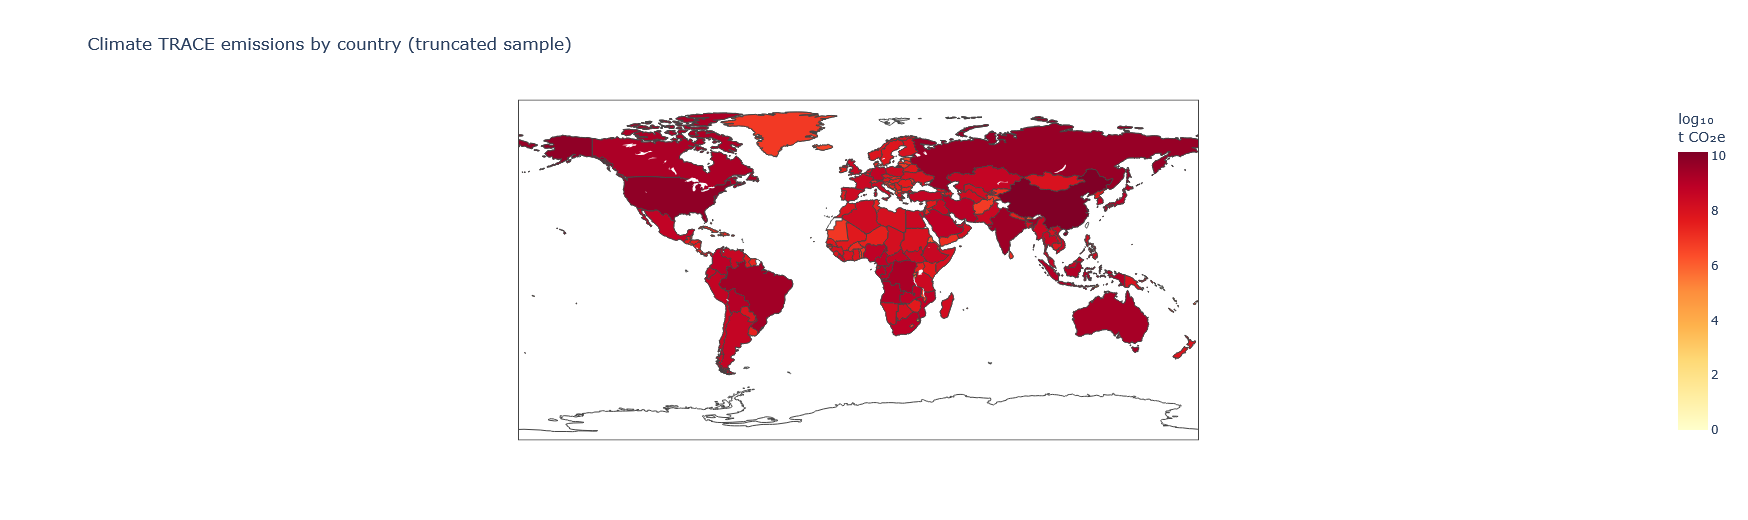

In [20]:
rollup = ed.country_rollup(ct, countries)
rollup = rollup[rollup["income_level"].notna()]
print(f"{len(rollup)} countries with both Climate TRACE and World Bank data")

fig = px.choropleth(
    rollup, locations="iso3", color=np.log10(rollup["total_co2e"].clip(lower=1)),
    hover_name="country",
    hover_data={"n_sources": True, "total_co2e": ":,.0f",
                "income_level": True, "iso3": False},
    color_continuous_scale="YlOrRd",
    labels={"color": "log10 t CO2e"},
    title="Climate TRACE emissions by country (truncated sample)")
fig.update_layout(height=520,
                  coloraxis_colorbar=dict(title="log₁₀<br>t CO₂e"))
fig.show()

**Caveat that belongs on the chart, not in a footnote.** This is not a
national emissions inventory. It is the sum of the largest sources per sector
that survived a pagination cap. Countries with many mid-sized emitters are
understated relative to countries with a few huge ones.

A responsible version of this map would either fix the sampling or label the
axis honestly. We are doing the second.

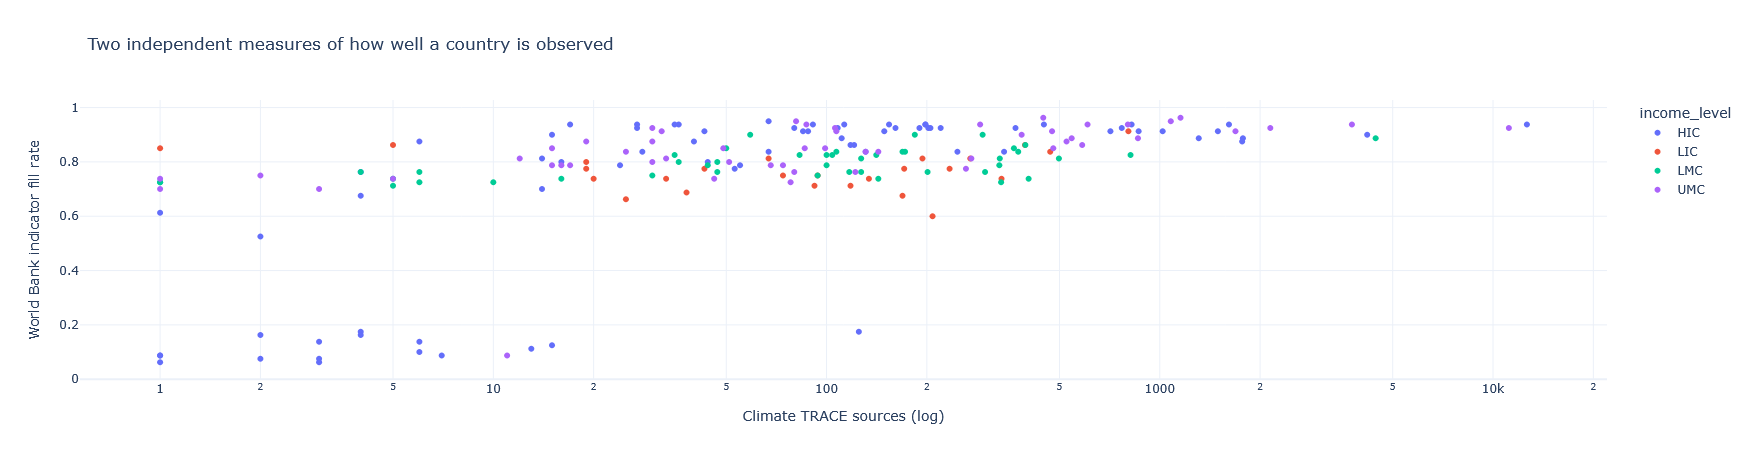

Spearman correlation between the two coverage measures: 0.58


In [21]:
# Do asset counts track the sovereign panel's own coverage?
panel = ed.load_worldbank_panel()
ind = ed.indicator_columns(panel)
latest = panel[panel["year"] == 2020].copy()
latest["wb_fill"] = latest[ind].notna().mean(axis=1)

j = rollup.merge(latest[["iso3", "wb_fill"]], on="iso3", how="inner")

fig = px.scatter(j, x="n_sources", y="wb_fill", color="income_level",
                 hover_name="country", log_x=True,
                 labels={"n_sources": "Climate TRACE sources (log)",
                         "wb_fill": "World Bank indicator fill rate"},
                 title="Two independent measures of how well a country is observed")
fig.update_layout(height=460)
fig.show()

print("Spearman correlation between the two coverage measures: "
      f"{j['n_sources'].corr(j['wb_fill'], method='spearman'):.2f}")

The two coverage measures are related but far from interchangeable — a rank
correlation around 0.6 leaves a great deal of disagreement. Countries sit well
off the diagonal in both directions: some are richly observed by satellite and
thinly by their own statistical office, and some the reverse.

They fail in different places, which is exactly why triangulating across
sources with partly independent biases is worth the join cost — the argument
on the source-tiers slide in the lecture.

---
## 9. The attribution gap

We can say, to within a few hundred metres, where a large share of the world's
industrial emissions physically occur. We cannot say from this file whose they
are.

In [22]:
print(f"owner populated: {ct['owner'].notna().mean():.1%} of {len(ct):,} rows")
print("\nWhat we have per source:")
print(ct[["source_name", "sector", "lat", "lon",
          "emissions_quantity", "capacity"]].head(3).to_string(index=False))
print("\nWhat a portfolio analyst needs but cannot get from this file:")
for missing in ["operator", "immediate owner", "ultimate parent",
                "ownership share (%)", "listed entity / ticker", "LEI"]:
    print(f"   - {missing}")

owner populated: 0.0% of 78,924 rows

What we have per source:
        source_name             sector        lat        lon  emissions_quantity     capacity
    Lebedinsky Mine mineral-extraction  51.280537  37.630765        2.602541e+06 4.560000e+10
Sarcheshmeh Complex mineral-extraction  29.947311  55.866683        2.178631e+06 1.440000e+10
    Antapaccay Mine mineral-extraction -14.884351 -71.313260        1.928869e+06 5.508000e+09

What a portfolio analyst needs but cannot get from this file:
   - operator
   - immediate owner
   - ultimate parent
   - ownership share (%)
   - listed entity / ticker
   - LEI


This is the **attribution gap**, and it is where facility data stops being
automatically useful for finance.

Getting from a coordinate to a security requires a chain of joins, each with
its own failure rate:

> facility → operator → immediate owner → ultimate parent → listed entity → LEI → ISIN

Climate TRACE does publish ownership, but not through the `/v7/sources`
endpoint this snapshot used. It is available through `/v7/owners`, through the
bulk packages, and as a full nodes-and-edges network on request.

Note what this does to a footprint calculation. A 40% stake in a joint venture
is fully in, partly in, or wholly out depending on whether you use equity
share, operational control or financial control — the consolidation-boundary
problem from the lecture. The coordinate is precise; the attribution is a
modelling choice.

> **Core exercise 9.1** — Take the ten largest Australian point facilities.
> Using public sources, identify the operator and the ultimate listed parent
> for each. Record how many required more than one lookup, and how many you
> could not resolve confidently. That failure rate is your real attribution
> accuracy.
>
> **Stretch exercise 9.2** — Query `https://api.climatetrace.org/v7/owners`
> with `search_owners(name=...)` for those parents, then re-query `/v7/sources`
> with `owner_ids` to pull every asset they hold. Compare the total against the
> firm's reported Scope 1. Any discrepancy is a research question, not an error.

---
## 10. Exercises

### Core

1. **Audit your own snapshot.** Run `ed.snapshot_health()`, then write a
   150-word data-limitations paragraph of the kind that should accompany any
   figure built from this file.

2. **Fix the country filter.** The fetch script sent `gadm_id=AUS` and the API
   ignored it. Write a corrected version that filters client-side on the
   returned `country` field and pages until a target count is reached. How many
   requests would a complete Australian inventory take?

3. **Match quality as a variable.** Recreate the HQ map with marker size or
   colour driven by `class`. Would you show this to a client as-is?

4. **Point vs aggregate.** Produce two Australian choropleths of emissions by
   state: one using all rows, one using point facilities only. Explain the
   difference.

### Stretch

5. **Physical risk proxy.** Join facility coordinates to a public flood or
   cyclone hazard layer and compute an exposure score per facility. Aggregate
   to country and compare against the World Bank's own climate indicators.

6. **The full attribution chain.** For the ASX 20, build
   facility → owner → parent → ticker and report the resolution rate at each
   hop. The compounding is the finding.

7. **Rebuild the geocoding.** Re-run all 250 addresses through
   `hq_address_clean`, cache to disk, and quantify how much of the original
   49% failure the two cheap fixes recover.

---

### What to take away

* A file that loads cleanly can still be the wrong file. Check before you trust.
* A coordinate is not a place: know whether a row is a facility or a polygon.
* Geocoding failure is systematic, and here it tracked jurisdiction directly.
* Match quality is data. Dropping it imputes precision you never had.
* Headquarters tells you almost nothing about physical exposure.
* Knowing *where* emissions are is not knowing *whose* they are.

### Where next

Lab **7b** takes the World Bank panel used in Section 8 and works through
missingness mechanisms and the imputation ladder. Lab **7c** is the clustering
playground behind the peer-group construction referenced in Section 7.